In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import scqubits as scq

import floquet as ft

### Run for a transmon

In [2]:
filepath = ft.generate_file_path("h5py", "transmon_floquet", "out")

# Transmon parameters
num_states = 20
# These parameters give a transmon with E10 = 5.45 GHz, alpha = -219 MHz
qubit_params = {"EJ": 20.0, "EC": 0.2, "ng": 0.25, "ncut": 41}
tmon = scq.Transmon(**qubit_params, truncated_dim=num_states)
state_indices = [0, 1]  # get data for ground and first excited states


# Express operators in eigenbasis of transmon
def get_H0_H1(qubit_instance):
    hilbert_space = scq.HilbertSpace([qubit_instance])
    hilbert_space.generate_lookup()
    evals = hilbert_space["evals"][0][0:num_states]
    H0 = 2.0 * np.pi * qt.Qobj(np.diag(evals - evals[0]))
    H1 = hilbert_space.op_in_dressed_eigenbasis(qubit_instance.n_operator)
    return H0, H1


H0, H1 = get_H0_H1(tmon)

# Drive parameters
# Drive frequencies to scan over
omega_d_values = 2.0 * np.pi * np.linspace(7.5, 10.0, 120)
# Induced ac stark shifts to scan over
chi_ac_values = 2.0 * np.pi * np.linspace(0.0, 0.1, 59)
# To achieve same range of chi_ac for the various drive frequencies, need different
# drive amplitudes. This utility computes the linear drive strength required to achieve
# a desired induced ac-Stark shift for the various drive frequencies.
chi_to_amp = ft.ChiacToAmp(H0, H1, state_indices, omega_d_values)
# drive_amplitudes has shape (a,w), where a is amplitude and w is frequency
drive_amplitudes = chi_to_amp.amplitudes_for_omega_d(chi_ac_values)

# initialize the model to pass to FloquetAnalysis
model = ft.Model(
    H0, H1, omega_d_values=omega_d_values, drive_amplitudes=drive_amplitudes
)

options = ft.Options(
    fit_range_fraction=0.5,  # split the fit into segments based on this fraction
    floquet_sampling_time_fraction=0.0,  # fraction of the period to compute the Floquet modes  # noqa E501
    fit_cutoff=4,  # polynomial cutoff
    overlap_cutoff=0.9,  # cutoff for excluding from the fit
    nsteps=30_000,  # qutip integration parameter
    num_cpus=6,  # number of cpus to use to compute Floquet modes in parallel
    save_floquet_modes=True,  # whether or not to save floquet modes themselves
)

In [3]:
floquet_analysis = ft.FloquetAnalysis(
    model, state_indices=state_indices, options=options
)
data_vals = floquet_analysis.run(filepath=filepath)

Running floquet simulation with parameters: 
model: H0: Quantum object: dims=[[20], [20]], shape=(20, 20), type='oper', dtype=Dense, isherm=True
Qobj data =
[[  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.        ]
 [  0.          34.23724704   0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.        ]
 [  0.           0.          67.09785619   0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.        ]
 [  0.           0.           0.          98.47961089   0.
    0.           0.           0.           0.    

In [4]:
new_obj, new_data_dict = ft.read_from_file(filepath)

In [5]:
def print_dict(_dict, iter_val=1):
    iter_tab = "|      " * (iter_val - 1) + "|---> "

    for key, value in _dict.items():
        if isinstance(value, dict):
            print(f"{iter_tab}{key}: {type(value)}")
            print_dict(value, iter_val + 1)
        elif isinstance(value, ft.model.Model) or isinstance(value, ft.options.Options):
            print(f"{iter_tab}{key}: {type(value)}")
            print_dict(value.__dict__, iter_val + 1)
        elif isinstance(value, np.ndarray) or isinstance(value, qt.Qobj):
            print(f"{iter_tab}{key}: ndarray of shape {value.shape}")
        else:
            print(f"{iter_tab}{key}: {value}")


print("new_obj.__dict__:")
print_dict(new_obj.__dict__)
print()
print("new_data_dict:")
print_dict(new_data_dict)

new_obj.__dict__:
|---> model: <class 'floquet.model.Model'>
|      |---> H0: ndarray of shape (20, 20)
|      |---> H1: ndarray of shape (20, 20)
|      |---> omega_d_values: ndarray of shape (120,)
|      |---> drive_amplitudes: ndarray of shape (59, 120)
|---> state_indices: ndarray of shape (2,)
|---> options: <class 'floquet.options.Options'>
|      |---> fit_range_fraction: 0.5
|      |---> floquet_sampling_time_fraction: 0.0
|      |---> fit_cutoff: 4
|      |---> overlap_cutoff: 0.9
|      |---> nsteps: 30000
|      |---> num_cpus: 6
|      |---> save_floquet_modes: True
|---> init_data_to_save: None
|---> hilbert_dim: 20

new_data_dict:
|---> avg_excitation: ndarray of shape (120, 59, 20)
|---> bare_state_overlaps: ndarray of shape (120, 59, 2)
|---> displaced_state_overlaps: ndarray of shape (120, 59, 2)
|---> fit_data: ndarray of shape (2, 20, 9)
|---> floquet_modes: ndarray of shape (120, 59, 2, 20)
|---> intermediate_displaced_state_overlaps: ndarray of shape (120, 59, 2)


In [6]:
def plot_disp_state_ovlps(displaced_state_overlaps, state_idx):
    plot_data = np.clip(1 - displaced_state_overlaps[:, :, state_idx].T ** 2, 0.0, 0.5)

    fig, ax = plt.subplots(figsize=(8, 8))
    xticks = omega_d_values / (2.0 * np.pi)
    yticks = chi_ac_values / (2.0 * np.pi)
    num_x_pts = len(xticks)
    num_y_pts = len(yticks)
    im = plt.imshow(
        plot_data, origin="lower", cmap="Blues", aspect=0.75, interpolation="none"
    )
    ax.set_title(f"$P_{state_idx}$" + r"$\rightarrow$", fontsize=15)
    xticklabel_locations = np.linspace(0, num_x_pts - 1, 6, dtype=int)
    ax.set_xticks(xticklabel_locations)
    ax.set_xticklabels(
        np.array(np.around(xticks[xticklabel_locations], decimals=2), dtype=str),
        fontsize=12,
    )
    yticklabel_locations = np.linspace(0, num_y_pts - 1, 3, dtype=int)
    ax.set_yticks(yticklabel_locations)
    ax.set_yticklabels(
        np.array(np.around(yticks[yticklabel_locations], decimals=2), dtype=str),
        fontsize=12,
    )
    ax.set_ylabel(r"$\chi_{\rm ac}$ [GHz]", fontsize=15)
    ax.set_xlabel(r"$\omega_r/2\pi$ [GHz]", fontsize=15)
    cax = plt.axes([0.91, 0.35, 0.05, 0.3])
    cbar = plt.colorbar(im, cax=cax)
    plt.show()

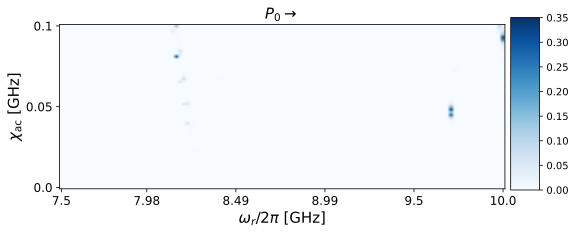

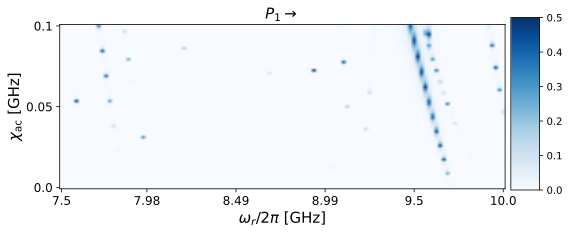

In [7]:
coeffs = new_data_dict["fit_data"]

for i in state_indices:
    plot_disp_state_ovlps(new_data_dict["displaced_state_overlaps"], i)

### New Code

In [8]:
import time
import warnings

import numpy as np

# from qutip import FloquetBasis
import qutip as qt

from floquet.model import Model
from floquet.options import Options
from floquet.utils.file_io import Serializable
from floquet.utils.parallel import parallel_map


####################################################################################################
# Displaced state code
####################################################################################################


class DisplacedState:
    """Class providing methods for computing displaced states.

    Parameters:
        hilbert_dim: Hilbert space dimension
        model: Model including the Hamiltonian, drive amplitudes, frequencies,
            state indices
        state_indices: States of interest
        options: Options used
    """

    def __init__(
        self, hilbert_dim: int, model: Model, state_indices: list, options: Options
    ):
        self.hilbert_dim = hilbert_dim
        self.model = model
        self.state_indices = state_indices
        self.options = options
        self.exponent_pairs = self._create_exponent_pairs()
        self.poly_terms = self._create_poly_terms()

    # a little hacky
    @staticmethod
    def model_bare_state_array(model):
        return np.identity(model.H0.shape[-1])

    def overlap_with_bare_states(
        self,
        coefficients: np.ndarray,
        floquet_modes: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idx_0: int = 0,
        cartesian_overlaps: bool = False,
    ) -> np.ndarray:
        """Calculate overlap of floquet modes with 'bare' states.

        'Bare' here is defined loosely. For the first range of amplitudes, the bare
        states are truly the bare states (all zero coefficients). For later ranges, we
        define the bare state as the state obtained from the fit from previous range,
        with amplitude evaluated at the lower edge of amplitudes for the new region.
        This is, in a sense, the most natural choice, since it is most analogous to what
        is done in the first window when the overlap is computed against bare
        eigenstates (that obviously don't have amplitude dependence). Moreover, the fit
        coefficients for the previous window by definition were obtained in a window
        that does not include the one we are currently investigating. Asking for the
        state with amplitude values outside of the fit window should be done at your
        own peril.

        Parameters:
            coefficients: coefficients that specify the bare state that we calculate
                overlaps of Floquet modes against.
                Shape: (num_states, hilbert_dim, num_fit_terms).
            floquet_modes: Floquet modes to be compared to the bare states given by
                coefficients. The -2 dimension here indexes the modes and the
                -1 dimension indexes the hilbert space.
                Shape: (..., hilbert_dim, hilbert_dim).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idx_0: Index specifying the lower bound of the amplitude range.
                0 by default, i.e. selects the undriven states.
            cartesian_overlaps: If True, compute overlaps between all possible pairs of
                displaced states and floquet modes. If False, only compute overlaps of each
                floquet mode with the corresponding displaced state.
        Returns:
            Overlaps between all the floquet modes and the displaced states specified
                by self.state_indices.
                If cartesian_overlaps is True, shape: (..., num_states, num_floquet_modes).
                Here, the -2 dimension indexes the displaced state, and the -1 dimension
                indexes the floquet modes.
                If cartesian_overlaps is False, shape: (..., num_states).
                Here, only the -1 dimension indexes the states (both displaced and floquet).
        """

        floquet_modes = floquet_modes[
            omega_d_idxs[0] : omega_d_idxs[1], :, self.state_indices, :
        ]

        displaced_states = self.displaced_state(
            coefficients, omega_d_idxs, [amp_idx_0, amp_idx_0 + 1]
        )[:, 0, ...]

        return np.abs(
            np.einsum("wsh,wash->was", np.conj(displaced_states), floquet_modes)
        )

    def overlap_with_displaced_states(
        self,
        coefficients: np.ndarray,
        floquet_modes: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idxs: tuple[int, int] = (0, None),
    ) -> np.ndarray:
        """Calculate overlap of floquet modes with 'ideal' displaced states.

        This is done here for a specific amplitude range.

        Parameters:
            coefficients: coefficients that specify the displaced state that we calculate
                overlaps of Floquet modes against.
                Shape: (num_states, hilbert_dim, num_fit_terms).
            floquet_modes: Floquet modes to be compared to the bare states given by
                coefficients.
                Shape: (num_omega_ds, num_amps, num_states, hilbert_dim).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idxs: Indices specifying the lower and upper bound of the amplitude range.
                Selects all self.model.drive_amplitudes by default.
        Returns:
            Overlaps. Shape: (num_omega_ds, num_amps, num_states).
        """
        floquet_modes = floquet_modes[
            omega_d_idxs[0] : omega_d_idxs[1],
            amp_idxs[0] : amp_idxs[1],
            self.state_indices,
            :,
        ]
        displaced_states = self.displaced_state(coefficients, omega_d_idxs, amp_idxs)
        return np.abs(
            np.einsum("wash,wash->was", np.conj(displaced_states), floquet_modes)
        )

    def displaced_state(
        self,
        coefficients: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idxs: tuple[int, int] = (0, None),
    ) -> np.ndarray:
        """Construct the ideal displaced state, $\left| \tilde{n} (\omega_d, \Omega_d) \right>$ based on a low-order perturbation around the corresponding bare state.
        $$
        \left| \tilde{n} (\omega_d, \Omega_d) \right> = \left| n \right> + \sum_l \sum_{k_0, k_1} c_{n, l, k_0, k_1} \omega_d^{k_0} \Omega_d^{k_1} \left| l \right>
        $$
        where the coefficients $c_{n, l, k_0, k_1}$ are provided in the `coefficients` argument.
        The constant term (i.e. $k_0 = k_1 = 0$) is excluded from the fit, as indicated by the
        Kronecker delta $\delta_{n,l}$. Note, that the (k_0, k_1) indices are stacked, and provided
        in the order specified by `self.exponent_pairs`.

        Parameters:
            coefficients: Coefficients to expand the displaced state in terms of the undriven
                states. Shape: (num_states, hilbert_dim, num_fit_terms).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idxs: Indices specifying the lower and upper bound of the amplitude range.
                Selects all self.model.drive_amplitudes by default.

        Returns:
            The displaced state(s). Shape: (num_omega_ds, num_amps, num_states, hilbert_dim).
            Careful, that the num_states index is the array index, not the state index! For example,
            if state_indices = [0, 2], then result[0, ...] is the displaced state for state index
            0, and result[1, ...] is the displaced state for state index 2.
        """
        # Tensor of polynomial terms omega^{k_0} * amp^{k_1}.
        # Shape: (num_omega_ds, num_amps, num_fit_terms)
        _poly_terms = self.poly_terms[
            omega_d_idxs[0] : omega_d_idxs[1], amp_idxs[0] : amp_idxs[1], :
        ]

        # Compute the perturbation, based on the given coefficients.
        result = np.einsum("wat,sht->wash", _poly_terms, coefficients)

        # Add the perturbation to the bare state. Bare states are defined by the model.
        # Get only the states corresponding to state_indices, and tile them for all
        # omega_ds and amps.
        result += np.tile(
            self.model_bare_state_array(self.model)[None, None, self.state_indices, :],
            (*result.shape[:2], 1, 1),
        )

        # Normalize
        result /= np.linalg.norm(result, axis=-1, keepdims=True)

        return result

    def _create_poly_terms(self) -> np.ndarray:
        """Compute a tensor, where each component is a polynomial term
        omega^{k_0} * amp^{k_1} for all (omega, amp, fit_terms).
        """
        omega_power = (
            self.model.omega_d_values[:, None, None]
            ** self.exponent_pairs[0][None, None, :]
        )
        amp_power = (
            self.model.drive_amplitudes.T[:, :, None]
            ** self.exponent_pairs[1][None, None, :]
        )
        return omega_power * amp_power

    def _create_exponent_pairs(self) -> np.ndarray:
        """Create dictionary of terms in polynomial that we fit.

        We truncate the fit if e.g. there is only a single frequency value to scan over
        but the fit is nominally set to order four. We additionally eliminate the
        constant term that should always be either zero or one.
        """
        cutoff_omega_d = min(len(self.model.omega_d_values), self.options.fit_cutoff)
        cutoff_amp = min(len(self.model.drive_amplitudes), self.options.fit_cutoff)
        # Generate all combinations of indices.
        # Remove amplitude-independent terms (i.e. when the exponent for the amp == 0).
        # This is enforced by the fact the states have to agree at zero drive strength.
        idx_exp_map = np.stack(
            np.meshgrid(
                np.arange(cutoff_omega_d), np.arange(1, cutoff_amp), indexing="ij"
            ),
            axis=-1,
        ).reshape(-1, 2)

        # Only keep terms where the sum of the exponents is less than the cutoff
        idx_exp_map = idx_exp_map[
            np.sum(idx_exp_map, axis=-1) <= self.options.fit_cutoff
        ]

        # Sort. Introduce a fudge factor to ensure that the sorting is stable
        # Only keep terms where the sum of the exponents is less than the cutoff
        weighted_vals = 1.01 * idx_exp_map[:, 0] + idx_exp_map[:, 1]
        sorted_idxs = np.argsort(weighted_vals)
        return idx_exp_map[sorted_idxs].T


class DisplacedStateFit(DisplacedState):
    """Methods for fitting an ideal displaced state to calculated Floquet modes."""

    def displaced_states_fit(
        self,
        ovlp_with_bare_states: np.ndarray,
        floquet_modes: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idxs: tuple[int, int] = (0, None),
    ) -> np.ndarray:
        """Perform a fit for the indicated range, ignoring specified modes.

        We loop over all states in state_indices and perform the fit for a given
        amplitude range. We ignore floquet modes (not included in the fit) where
        the corresponding value in ovlp_with_bare_states is below the threshold
        specified in options.

        Parameters:
            ovlp_with_bare_states: Overlap with bare states. Already trimmed to the
                relevant range of frequencies and amplitudes.
                Shape: (num_omega_d_in_range, num_amps_in_range, num_states).
            floquet_modes: Floquet modes.
                Shape: (num_omega_ds, num_amps, num_states, hilbert_dim).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idxs: Indices specifying the lower and upper bound of the amplitude range.
                Selects all self.model.drive_amplitudes by default.

        Returns:
            Optimized fit coefficients. Shape: (num_states, hilbert_dim, num_fit_terms).
        """

        # Only fit states that we think haven't run into a transition,
        # and those within the specified bounds
        # mask.shape = (num_omega_ds, num_amps, num_state_indices).
        mask = ovlp_with_bare_states > self.options.overlap_cutoff

        # Required poly_terms
        poly_terms = self.poly_terms[
            omega_d_idxs[0] : omega_d_idxs[1], amp_idxs[0] : amp_idxs[1], :
        ]

        # Fit each state separately, since their masks may differ
        coeffs = np.zeros(
            (len(self.state_indices), self.hilbert_dim, self.exponent_pairs.shape[-1]),
            dtype=complex,
        )

        for arr_idx, state_idx in enumerate(self.state_indices):
            coeffs[arr_idx] = self._fit_for_state_idx(
                target_states=np.real(floquet_modes[..., state_idx, :]),
                mask=mask[..., state_idx],
                state_index=state_idx,
                poly_terms=poly_terms,
            )

        # TODO: return mask, other fit data
        return coeffs

    def _fit_for_state_idx(
        self,
        target_states: np.ndarray,
        mask: np.ndarray,
        state_index: int,
        poly_terms: np.ndarray,
    ) -> np.ndarray:
        num_fit_terms = self.exponent_pairs.shape[-1]
        mask_flat = mask.ravel()

        # Warn if not enough data points to fit
        if len(mask_flat) < (self.hilbert_dim * num_fit_terms):
            warnings.warn(
                "Not enough data points to fit. Returning zeros for the fit",
                stacklevel=3,
            )
            return np.zeros((self.hilbert_dim, num_fit_terms), dtype=float)

        # Flatten and mask arrays. Resulting rows index masked amp-freq pairs.
        # For the poly_terms matrix, the cols index the fit terms.
        # For states, the cols index the hilbert_dim
        masked_poly_terms = poly_terms.reshape(-1, num_fit_terms)[mask_flat]
        masked_target_states = target_states.reshape(-1, self.hilbert_dim)[mask_flat]

        # Bare states array (repeated for all amp-freq pairs)
        masked_bare_states = np.tile(
            self.model_bare_state_array(self.model)[None, state_index, :],
            (masked_target_states.shape[0], 1),
        )

        # Fit the difference between the target states and the bare states
        masked_states_to_fit = masked_target_states - masked_bare_states

        # Simple linear fit: masked_states_to_fit = masked_poly_terms @ coefficients.T
        try:
            popt = np.linalg.lstsq(masked_poly_terms, masked_states_to_fit)[0].T

        except RuntimeError:
            warnings.warn("Fit failed. Returning zeros for the fit", stacklevel=3)
            popt = np.zeros((self.hilbert_dim, num_fit_terms), dtype=float)

        return popt


####################################################################################################
# Floquet code
####################################################################################################
class FloquetAnalysis(Serializable):
    """Perform a floquet analysis to identify nonlinear resonances.

    In most workflows, one needs only to call the run() method which performs
    both the displaced state fit and the Blais branch analysis. For an example
    workflow, see the [transmon](../examples/transmon) tutorial.

    Parameters:
        model: Class specifying the model, including the Hamiltonian, drive amplitudes,
            frequencies
        state_indices: State indices of interest. Defaults to [0, 1], indicating the two
            lowest-energy states.
        options: Options for the Floquet analysis.
            ??? info "Detailed `opt_options` API"
                - fit_range_fraction (`float`, default: 1.0): Fraction of the amplitude
                    range to sweep over before changing the definition of the bare state
                    to that of the itted state from the previous range. For instance if
                    fit_range_fraction=0.4, then the amplitude range is split up into
                    three chunks: the first 40% of the amplitude linspace, then from
                    40% -> 80%, then from 80% to the full range. For the first fraction
                    of amplitudes, they are compared to the bare eigenstates for
                    identification. For the second range, they are compared to the
                    fitted state from the first range. And so on. Defaults to 1.0,
                    indicating that no iteration is performed.
                - floquet_sampling_time_fraction (`float`, default: 0.0): What point of
                    the drive period we want to sample the Floquet modes. Defaults to
                    0.0, indicating the floquet modes at t=0*T where T is the drive
                    period.
                - fit_cutoff (`int`, default: 4): Cutoff for the fit polynomial of the
                    displaced state.
                - overlap_cutoff (`float`, default: 0.8): Cutoff for fitting overlaps.
                    Floquet modes with overlap with the "bare" state below this cutoff
                    are not included in the fit (as they may be experiencing a
                    resonance).
                - nsteps (`int`, default: 30_000): QuTiP integration parameter, number
                    of steps the solver can take.
                - num_cpus (`int`, default: 1): Number of cpus to use in parallel
                    computation of Floquet modes over the different values of
                    omega_d, amp.
                - save_floquet_modes (`bool`, default: False): Indicating whether to
                    save the extracted Floquet modes themselves. Such data is often
                    unnecessary and requires a fair amount of storage, so the default is
                    False.
        init_data_to_save: Initial parameter metadata to save to file. Defaults to None.
    """

    def __init__(
        self,
        model: Model,
        state_indices: list | None = None,
        options: Options = Options(),  # noqa B008
        init_data_to_save: dict | None = None,
    ):
        if state_indices is None:
            state_indices = [0, 1]
        self.model = model
        self.state_indices = state_indices
        self.options = options
        self.init_data_to_save = init_data_to_save
        self.hilbert_dim = model.H0.shape[0]

    def __str__(self) -> str:
        return "Running floquet simulation with parameters: \n" + super().__str__()

    # a little hacky
    @staticmethod
    def model_bare_state_array(model):
        return np.identity(model.H0.shape[-1])

    def run_one_floquet(
        self, omega_d_amp: tuple[float, float]
    ) -> tuple[np.ndarray, np.ndarray]:
        """Run one instance of the problem for a pair of drive frequency and amp.

        Returns:
            Floquet modes. Shape: (hilbert_dim, hilbert_dim), where the first index
                labels the mode and the second the basis vector components.
            Quasienergies. Shape: (hilbert_dim,)

        Parameters:
            omega_d_amp: Pair of drive frequency and amp.
        """
        omega_d, _ = omega_d_amp
        T = 2.0 * np.pi / omega_d
        fbasis = qt.FloquetBasis(
            self.model.hamiltonian(omega_d_amp),
            T,
            options={"nsteps": self.options.nsteps},  # type: ignore
        )
        sampling_time = self.options.floquet_sampling_time_fraction * T % T
        f_modes_t = fbasis.mode(sampling_time, data=True).to_array()
        f_energies = np.real(fbasis.e_quasi)
        return f_modes_t.T, f_energies

    def identify_floquet_modes(
        self,
        floquet_modes: np.ndarray,
        displaced_state: DisplacedState,
        previous_coefficients: np.ndarray,
        omega_d_idx: int,
        amp_idx_0: int = 0,
    ) -> np.ndarray:
        """Return floquet modes with largest overlap with ideal displaced state.

        Also return that overlap value.

        Parameters:
            floquet_modes: Shape: (hilbert_dim, hilbert_dim), where the first index
                labels the mode and the second the basis vector components.
            displaced_state: Instance of DisplacedState.
            previous_coefficients: Coefficients from the previous amplitude range that
                will be used when calculating overlap of the floquet modes against
                the 'bare' states specified by previous_coefficients.
            omega_d_idx: Index of the drive frequency in self.model.omega_d_values.
            amp_idx_0: Index specifying the lower bound of the amplitude range.
                0 by default, i.e. selects the undriven states.
        """

        # Compute the overlap of the floquet modes with the displaced states specified
        # Result = (self.state_indices, self.hilbert_dim)
        # TODO: could simply precompute these
        displaced_states = displaced_state.displaced_state(
            previous_coefficients,
            [omega_d_idx, omega_d_idx + 1],
            [amp_idx_0, amp_idx_0 + 1],
        )[0, 0, ...]
        overlaps = np.abs(
            np.einsum("ij,kj->ik", np.conj(displaced_states), floquet_modes)
        )

        # For each state index, find the floquet mode with the largest overlap
        f_idxs = np.argmax(np.abs(overlaps), axis=1)

        ovlps_and_modes = np.zeros(
            (len(self.state_indices), 1 + self.hilbert_dim), dtype=complex
        )
        for array_idx, _state_idx in enumerate(self.state_indices):
            f_idx = f_idxs[array_idx]
            bare_state_overlap = overlaps[array_idx, f_idx]
            ovlps_and_modes[array_idx, 0] = bare_state_overlap
            ovlps_and_modes[array_idx, 1:] = (
                np.sign(bare_state_overlap) * floquet_modes[f_idx, :]
            )
        return ovlps_and_modes

    def _step_in_amp(
        self, f_modes: np.ndarray, f_energies: np.ndarray, prev_f_modes: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Perform Blais branch analysis.

        Gorgeous in its simplicity. Simply calculate overlaps of new floquet modes with
        those from the previous amplitude step, and order the modes accordingly. So
        ordered, compute the mean excitation number, yielding our branches.
        """
        all_overlaps = np.abs(np.einsum("ij,kj->ik", np.conj(prev_f_modes), f_modes))
        # assume that prev_f_modes_arr have been previously sorted. Question
        # is which k index has max overlap?
        max_idxs = np.argmax(all_overlaps, axis=1)
        f_modes_ordered = f_modes[max_idxs]
        avg_excitation = self._calculate_mean_excitation(f_modes_ordered)
        return avg_excitation, f_modes_ordered, f_energies[max_idxs]

    def _calculate_mean_excitation(self, f_modes_ordered: np.ndarray) -> np.ndarray:
        """Mean excitation number of ordered floquet modes.

        Based on Blais arXiv:2402.06615, specifically Eq. (12) but going without the
        integral over floquet modes in one period.
        """
        bare_states = self.model_bare_state_array(model)
        overlaps_sq = np.abs(np.einsum("ij,kj->ik", bare_states, f_modes_ordered)) ** 2
        # sum over bare excitations weighted by excitation number
        return np.real(
            np.einsum("ik,i->k", overlaps_sq, np.arange(0, self.hilbert_dim))
        )

    def run(self, filepath: str | None = None) -> dict:
        """Perform floquet analysis over range of amplitudes and drive frequencies.

        This function largely performs two calculations. The first is the Xiao analysis
        introduced in https://arxiv.org/abs/2304.13656, fitting the extracted Floquet
        modes to the "ideal" displaced state which does not include resonances by design
        (because we fit to a low order polynomial and ignore any floquet modes with
        overlap with the bare state below a given threshold). This analysis produces the
        "scar" plots. The second is the Blais branch analysis, which tracks the Floquet
        modes by stepping in drive amplitude for a given drive frequency. For this
        reason the code is structured to parallelize over drive frequency, but scans in
        a loop over drive amplitude. This way the two calculations can be performed
        simultaneously.

        A nice bonus is that both of the above mentioned calculations determine
        essentially independently whether a resonance occurs. In the first, it is
        deviation of the Floquet mode from the fitted displaced state. In the second,
        it is branch swapping that indicates a resonance, independent of any fit. Thus
        the two simulations can be used for cross validation of one another.

        We perform these simulations iteratively over the drive amplitudes as specified
        by fit_range_fraction. This is to allow for simulations stretching to large
        drive amplitudes, where the overlap with the bare eigenstate would fall below
        the threshold (due to ac Stark shift) even in the absence of any resonances.
        We thus use the fit from the previous range of drive amplitudes as our new bare
        state.
        """
        # print(self)
        start_time = time.time()

        # initialize all arrays that will contain our data
        array_shape = (
            len(self.model.omega_d_values),
            len(self.model.drive_amplitudes),
            len(self.state_indices),
        )
        bare_state_overlaps = np.zeros(array_shape)
        # fit over the full range, using states identified by the fit over
        # intermediate ranges
        intermediate_displaced_state_overlaps = np.zeros(array_shape)
        floquet_modes = np.zeros((*array_shape, self.hilbert_dim), dtype=complex)
        avg_excitation = np.zeros(
            (
                len(self.model.omega_d_values),
                len(self.model.drive_amplitudes),
                self.hilbert_dim,
            )
        )
        quasienergies = np.zeros_like(avg_excitation)

        # for all omega_d, the bare states are identical at zero drive. We define
        # two sets of bare modes (prev_f_modes_arr and disp_coeffs_for_prev_amp)
        # because for the fit calculation, the bare modes are specified as fit
        # coefficients, whereas for the Blais calculation, the bare modes are specified
        # as actual kets.
        prev_f_modes_arr = np.tile(
            self.model_bare_state_array(model)[None, :, :],
            (len(self.model.omega_d_values), 1, 1),
        )
        displaced_state = DisplacedStateFit(
            hilbert_dim=self.hilbert_dim,
            model=self.model,
            state_indices=self.state_indices,
            options=self.options,
        )
        previous_coefficients = np.zeros(
            (
                len(self.state_indices),
                self.hilbert_dim,
                displaced_state.exponent_pairs.shape[-1],
            )
        )

        num_fit_ranges = int(np.ceil(1 / self.options.fit_range_fraction))
        num_amp_pts_per_range = int(
            np.floor(len(self.model.drive_amplitudes) / num_fit_ranges)
        )
        for amp_range_idx in range(num_fit_ranges):
            print(f"calculating for amp_range_idx={amp_range_idx}")
            # edge case if range doesn't fit in neatly
            if amp_range_idx == num_fit_ranges - 1:
                amp_range_idx_final = len(self.model.drive_amplitudes)
            else:
                amp_range_idx_final = (amp_range_idx + 1) * num_amp_pts_per_range
            amp_idxs = [amp_range_idx * num_amp_pts_per_range, amp_range_idx_final]
            # now perform floquet mode calculation for amp_range_idx
            # need to pass forward the floquet modes from the previous amp range
            # which allow us to identify floquet modes that may have been displaced
            # far from the origin
            output = self._floquet_main_for_amp_range(
                amp_idxs, displaced_state, previous_coefficients, prev_f_modes_arr
            )
            (
                bare_state_overlaps_for_range,
                floquet_modes_for_range,
                avg_excitation_for_range,
                quasienergies_for_range,
                prev_f_modes_arr,
            ) = output
            bare_state_overlaps = self._place_into(
                amp_idxs, bare_state_overlaps_for_range, bare_state_overlaps
            )
            floquet_modes = self._place_into(
                amp_idxs, floquet_modes_for_range, floquet_modes
            )
            avg_excitation = self._place_into(
                amp_idxs, avg_excitation_for_range, avg_excitation
            )
            quasienergies = self._place_into(
                amp_idxs, quasienergies_for_range, quasienergies
            )

            # ovlp_with_bare_states is used as a mask for the fit
            ovlp_with_bare_states = displaced_state.overlap_with_bare_states(
                previous_coefficients, floquet_modes_for_range, amp_idx_0=amp_idxs[0]
            )
            # Compute the fitted 'ideal' displaced state, excluding those
            # floquet modes experiencing resonances.
            new_coefficients = displaced_state.displaced_states_fit(
                ovlp_with_bare_states, floquet_modes_for_range, amp_idxs=amp_idxs
            )
            # Compute overlap of floquet modes with ideal displaced state using this
            # new fit. We use this data as the mask for when we compute the coefficients
            # over the whole range. Note that we pass in floquet_modes as
            # opposed to the more restricted floquet_modes_for_range since we
            # use indexing methods inside of overlap_with_displaced_states, so its
            # easier to pass in the whole array.
            overlaps = displaced_state.overlap_with_displaced_states(
                new_coefficients, floquet_modes, amp_idxs=amp_idxs
            )
            intermediate_displaced_state_overlaps = self._place_into(
                amp_idxs, overlaps, intermediate_displaced_state_overlaps
            )
            previous_coefficients = new_coefficients
        # The previously extracted coefficients were valid for the amplitude ranges
        # we asked for the fit over. Now armed with with correctly identified floquet
        # modes, we recompute these coefficients over the whole sea of floquet mode data
        # to get a plot that is free from numerical artifacts associated with
        # the fits being slightly different at the boundary of ranges. We utilize the
        # previously computed overlaps of the floquet modes with the displaced states
        # (stored in intermediate_displaced_state_overlaps) to obtain the mask with
        # which we exclude some data from the fit (because we suspect they've hit
        # resonances).
        full_displaced_fit = displaced_state.displaced_states_fit(
            intermediate_displaced_state_overlaps, floquet_modes
        )
        true_overlaps = displaced_state.overlap_with_displaced_states(
            full_displaced_fit, floquet_modes
        )
        data_dict = {
            "bare_state_overlaps": bare_state_overlaps,
            "fit_data": full_displaced_fit,
            "displaced_state_overlaps": true_overlaps,
            "intermediate_displaced_state_overlaps": intermediate_displaced_state_overlaps,  # noqa E501
            "quasienergies": quasienergies,
            "avg_excitation": avg_excitation,
        }
        if self.options.save_floquet_modes:
            data_dict["floquet_modes"] = floquet_modes
        print(f"finished in {(time.time() - start_time) / 60} minutes")
        if filepath is not None:
            self.write_to_file(filepath, data_dict)
        return data_dict

    @staticmethod
    def _place_into(
        amp_idxs: list, array_for_range: np.ndarray, overall_array: np.ndarray
    ) -> np.ndarray:
        overall_array[:, amp_idxs[0] : amp_idxs[1]] = array_for_range
        return overall_array

    def _floquet_main_for_amp_range(
        self,
        amp_idxs: list,
        displaced_state: DisplacedState,
        previous_coefficients: np.ndarray,
        prev_f_modes_arr: np.ndarray,
    ) -> tuple:
        """Run the floquet simulation over a specific amplitude range."""
        amp_range_vals = self.model.drive_amplitudes[amp_idxs[0] : amp_idxs[1]]

        def _run_floquet_and_calculate(
            omega_d: float,
        ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
            omega_d_idx = self.model.omega_d_to_idx(omega_d)
            amps_for_omega_d = amp_range_vals[:, omega_d_idx]
            avg_excitation_arr = np.zeros((len(amps_for_omega_d), self.hilbert_dim))
            quasienergies_arr = np.zeros_like(avg_excitation_arr)
            ovlps_and_modes_arr = np.zeros(
                (len(amps_for_omega_d), len(self.state_indices), 1 + self.hilbert_dim),
                dtype=complex,
            )
            prev_f_modes_for_omega_d = prev_f_modes_arr[omega_d_idx]
            # for evaluating the displaced state (might be dangerous to evaluate
            # outside of fitted window)
            params_0 = (omega_d, amp_range_vals[0, omega_d_idx])
            for amp_idx, amp in enumerate(amps_for_omega_d):
                params = (omega_d, amp)
                f_modes, f_energies = self.run_one_floquet(params)
                ovlps_and_modes = self.identify_floquet_modes(
                    f_modes,
                    displaced_state,
                    previous_coefficients,
                    omega_d_idx,
                    amp_idxs[0],
                )
                ovlps_and_modes_arr[amp_idx] = ovlps_and_modes
                avg_excitation, new_f_modes, new_energies = self._step_in_amp(
                    f_modes, f_energies, prev_f_modes_for_omega_d
                )
                avg_excitation_arr[amp_idx] = avg_excitation
                quasienergies_arr[amp_idx] = new_energies
                prev_f_modes_for_omega_d = new_f_modes
            return (
                ovlps_and_modes_arr,
                avg_excitation_arr,
                quasienergies_arr,
                prev_f_modes_for_omega_d,
            )

        floquet_data = list(
            parallel_map(
                self.options.num_cpus,
                _run_floquet_and_calculate,
                self.model.omega_d_values,
            )
        )
        (
            all_modes_quasies_ovlps,
            all_avg_excitation,
            all_quasienergies,
            f_modes_last_amp,
        ) = list(zip(*floquet_data, strict=True))
        floquet_mode_array = np.array(all_modes_quasies_ovlps, dtype=complex).reshape(
            (
                len(self.model.omega_d_values),
                len(amp_range_vals),
                len(self.state_indices),
                1 + self.hilbert_dim,
            )
        )
        f_modes_last_amp = np.array(f_modes_last_amp, dtype=complex).reshape(
            (len(self.model.omega_d_values), self.hilbert_dim, self.hilbert_dim)
        )
        all_avg_excitation = np.array(all_avg_excitation).reshape(
            (len(self.model.omega_d_values), len(amp_range_vals), self.hilbert_dim)
        )
        all_quasienergies = np.array(all_quasienergies).reshape(
            (len(self.model.omega_d_values), len(amp_range_vals), self.hilbert_dim)
        )
        bare_state_overlaps = np.abs(floquet_mode_array[..., 0])
        floquet_modes = floquet_mode_array[..., 1:]
        return (
            bare_state_overlaps,
            floquet_modes,
            all_avg_excitation,
            all_quasienergies,
            f_modes_last_amp,
        )

 <>: 141SyntaxWarning: invalid escape sequence '\l'
 <>: 141SyntaxWarning: invalid escape sequence '\l'
 /var/folders/fp/l4vdxgfn2jlgsvk5fw41sfyr0000gn/T/ipykernel_17144/2072601949.py: 141

In [9]:
options = ft.Options(
    fit_range_fraction=0.5,  # split the fit into segments based on this fraction
    floquet_sampling_time_fraction=0.0,  # fraction of the period to compute the Floquet modes  # noqa E501
    fit_cutoff=4,  # polynomial cutoff
    overlap_cutoff=0.9,  # cutoff for excluding from the fit
    nsteps=30_000,  # qutip integration parameter
    num_cpus=6,  # number of cpus to use to compute Floquet modes in parallel
    save_floquet_modes=True,  # whether or not to save floquet modes themselves
)

floquet_analysis = FloquetAnalysis(model, state_indices=state_indices, options=options)

filepath = ft.generate_file_path("h5py", "transmon_floquet_new", "out")
data_vals = floquet_analysis.run(filepath=filepath)

calculating for amp_range_idx=0
calculating for amp_range_idx=1
finished in 0.25043468475341796 minutes


In [10]:
new_obj2, new_data_dict2 = ft.read_from_file(filepath)
print("new_obj2.__dict__:")
print_dict(new_obj2.__dict__)
print()
print("new_data_dict2:")
print_dict(new_data_dict2)

new_obj2.__dict__:
|---> model: <class 'floquet.model.Model'>
|      |---> H0: ndarray of shape (20, 20)
|      |---> H1: ndarray of shape (20, 20)
|      |---> omega_d_values: ndarray of shape (120,)
|      |---> drive_amplitudes: ndarray of shape (59, 120)
|---> state_indices: ndarray of shape (2,)
|---> options: <class 'floquet.options.Options'>
|      |---> fit_range_fraction: 0.5
|      |---> floquet_sampling_time_fraction: 0.0
|      |---> fit_cutoff: 4
|      |---> overlap_cutoff: 0.9
|      |---> nsteps: 30000
|      |---> num_cpus: 6
|      |---> save_floquet_modes: True
|---> init_data_to_save: None
|---> hilbert_dim: 20

new_data_dict2:
|---> avg_excitation: ndarray of shape (120, 59, 20)
|---> bare_state_overlaps: ndarray of shape (120, 59, 2)
|---> displaced_state_overlaps: ndarray of shape (120, 59, 2)
|---> fit_data: ndarray of shape (2, 20, 9)
|---> floquet_modes: ndarray of shape (120, 59, 2, 20)
|---> intermediate_displaced_state_overlaps: ndarray of shape (120, 59, 2

In [11]:
# Blais data
assert np.allclose(new_data_dict2["avg_excitation"], new_data_dict["avg_excitation"])
assert np.allclose(new_data_dict2["quasienergies"], new_data_dict["quasienergies"])

assert np.allclose(
    new_data_dict2["bare_state_overlaps"], new_data_dict["bare_state_overlaps"]
)
assert np.allclose(
    new_data_dict2["displaced_state_overlaps"],
    new_data_dict["displaced_state_overlaps"],
)
assert np.allclose(
    new_data_dict2["intermediate_displaced_state_overlaps"],
    new_data_dict["intermediate_displaced_state_overlaps"],
)

print("All checks passed!")

# assert np.allclose(new_data_dict2['fit_data'], new_data_dict['fit_data'])
# assert np.allclose(new_data_dict2['floquet_modes'], new_data_dict['floquet_modes'])

All checks passed!


In [12]:
print(
    f"Max coeff discrepancy = {np.max(np.abs(new_data_dict2['fit_data'] - new_data_dict['fit_data'])):.3e}"
)

print(
    f"Max floquet mode discrepancy = {np.max(np.abs(new_data_dict2['floquet_modes'] - new_data_dict['floquet_modes'])):.3e}"
)

# Double checking the floquet modes
print(
    f"Max floquet mode mag discrepancy = {np.max(np.abs(new_data_dict2['floquet_modes']) - np.max(new_data_dict['floquet_modes'])):.3e}"
)
print(
    f"Max floquet mode angle discrepancy = {np.max(np.angle(new_data_dict2['floquet_modes']) - np.angle(new_data_dict['floquet_modes'])) / (np.pi):.3f} * pi"
)

Max coeff discrepancy = 8.686e-04
Max floquet mode discrepancy = 4.463e-05
Max floquet mode mag discrepancy = 0.000e+00+0.000e+00j
Max floquet mode angle discrepancy = 2.000 * pi
